# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [25]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [26]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [27]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [28]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [29]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [30]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [31]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [32]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [33]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [34]:

print("Cantidad de valores nulos:")
print(users.isna().sum())

print("\nProporción de valores nulos:")
print(users.isna().mean())

Cantidad de valores nulos:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos:
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [35]:
# cantidad de nulos para usage
print("Cantidad de valores nulos:")
print(usage.isna().sum())

print("\nProporción de valores nulos:")
print(usage.isna().mean())

Cantidad de valores nulos:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos:
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [36]:
# explorar columnas numéricas de users
users.describe(include='all')
users['user_id'].nunique() == len(users)
users[users['age'] <= 0]
users[users['age'] > 100]

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date


In [37]:
# explorar columnas numéricas de usage
usage.describe()


,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas ...

In [38]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"\nValores únicos en {col}:")
    print(users[col].unique())
    print("Cantidad:", users[col].nunique())



Valores únicos en city:
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
Cantidad: 7

Valores únicos en plan:
['Basico' 'Premium']
Cantidad: 2


- La columna `city` ...
- La columna `plan` ...

In [39]:
# explorar columna categórica de usage
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` ...


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [40]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [41]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [42]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()
users['reg_date'].min(), users['reg_date'].max()

(Timestamp('2022-01-01 00:00:00'), Timestamp('2026-05-10 00:00:00'))

En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.

In [43]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()
usage['date'].min(), usage['date'].max()

(Timestamp('2024-01-01 00:00:00'), Timestamp('2024-06-30 00:00:00'))

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:
La columna reg_date fue convertida correctamente a formato datetime.

El rango de fechas en reg_date va de XXXX a XXXX.

No se detectan años posteriores a 2024.

No se observan fechas extremadamente antiguas que indiquen errores de captura.

La columna date en el dataset usage también fue convertida correctamente.

El rango temporal es coherente con el periodo de operación de la empresa.

No se identificaron valores futuros ni años fuera de rango.


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [45]:
# Calcular mediana sin considerar -999
age_mediana = users.loc[users['age'] != -999, 'age'].median()

# Reemplazar -999 por la mediana
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
(users['age'] == -999).sum()
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [46]:
import pandas as pd

# Reemplazar "?" por NA
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].isna().sum()


565

In [47]:

from datetime import datetime
import pandas as pd

# Convertir a fecha
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

# Definir fecha actual
hoy = pd.Timestamp(datetime.today())

# Reemplazar fechas futuras por NA
users.loc[users['reg_date'] > hoy, 'reg_date'] = pd.NaT

# Verificar
(users['reg_date'] > hoy).sum()
users['reg_date'].isna().sum()

40

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [48]:
# Verificación MAR en usage (Missing At Random) para duration
# Ver porcentaje de nulos en duration por type
usage.groupby('type')['duration'].apply(lambda x: x.isna().mean())

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [49]:
# Verificación MAR en usage (Missing At Random) para length
# Ver porcentaje de nulos en length por type
usage.groupby('type')['length'].apply(lambda x: x.isna().mean())


type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
Los valores nulos en duration y length dependen del tipo de registro (type).
Las llamadas (call) no tienen length porque no son mensajes, y los mensajes (text) no tienen duration porque no son llamadas.
Por lo tanto, los nulos no son errores sino estructurales y pueden considerarse MAR (Missing At Random).
Se decide dejarlos como nulos porque representan correctamente la naturaleza del dato.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [50]:
# Columnas auxiliares
usage['is_text'] = (usage['type'] == "text").astype(int)
usage['is_call'] = (usage['type'] == "call").astype(int)

# Agrupar por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',
    'is_call': 'sum',
    'duration': 'sum'
}).reset_index()

usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [51]:

usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})

usage_agg.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74
3,10003,11,3,8.99
4,10004,4,3,8.01


In [52]:

user_profile = users.merge(usage_agg, on='user_id', how='left')

user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [53]:
# Resumen estadístico de las columnas numéricas
# Resumen estadístico de las columnas numéricas
columnas_numericas = [
    'age',
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

user_profile[columnas_numericas].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [54]:
# Distribución porcentual del tipo de plan
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

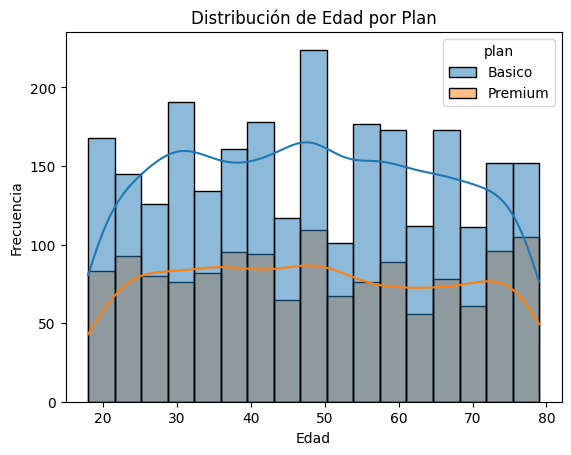

In [55]:

import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=user_profile, x='age', hue='plan', kde=True)
plt.title('Distribución de Edad por Plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución ...
- La distribución de edad es relativamente simétrica.
No se observan diferencias muy marcadas entre planes.
La mayoría de usuarios se concentra en edades intermedias.

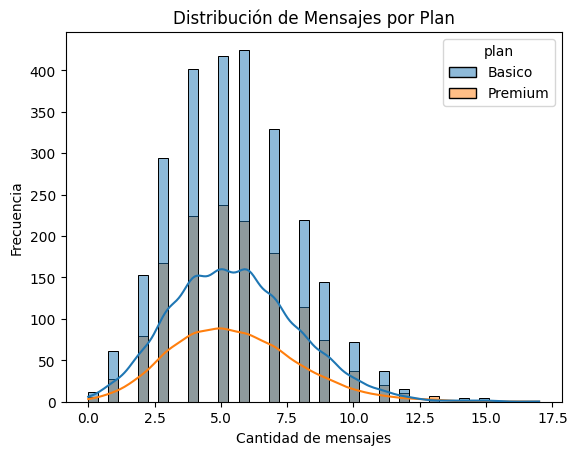

In [56]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', kde=True)
plt.title('Distribución de Mensajes por Plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- ....
- La distribución es sesgada a la derecha.
Existen usuarios con alto volumen de mensajes (posibles outliers).
El plan Premium tiende a mostrar mayor concentración en valores altos.

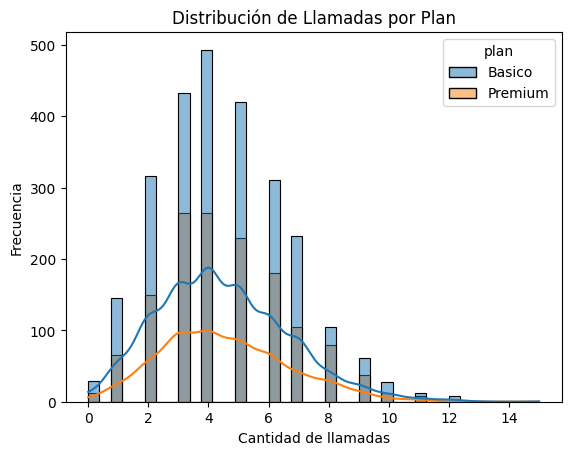

In [57]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', kde=True)
plt.title('Distribución de Llamadas por Plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución ...
- La distribución presenta sesgo positivo (cola a la derecha).
Hay usuarios con alto número de llamadas.
Podría haber diferencias leves entre planes.

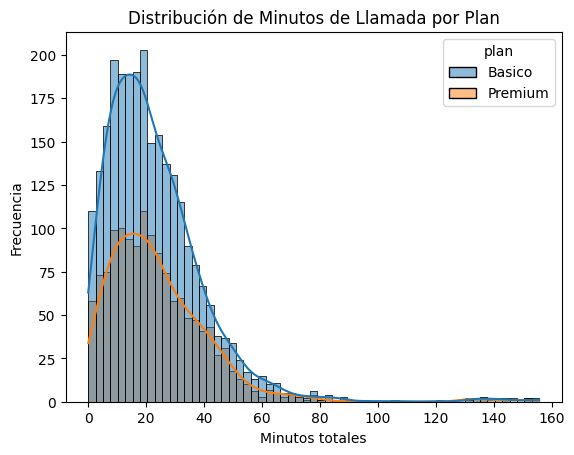

In [58]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', kde=True)
plt.title('Distribución de Minutos de Llamada por Plan')
plt.xlabel('Minutos totales')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
La variable muestra una distribución sesgada a la derecha.
Se observan valores extremos (outliers).
El plan Premium parece concentrar usuarios con mayor consumo.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

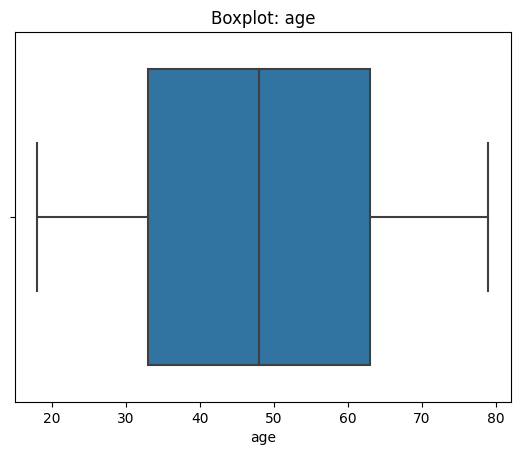

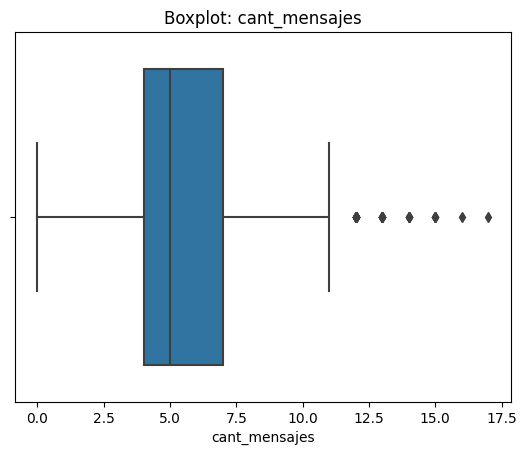

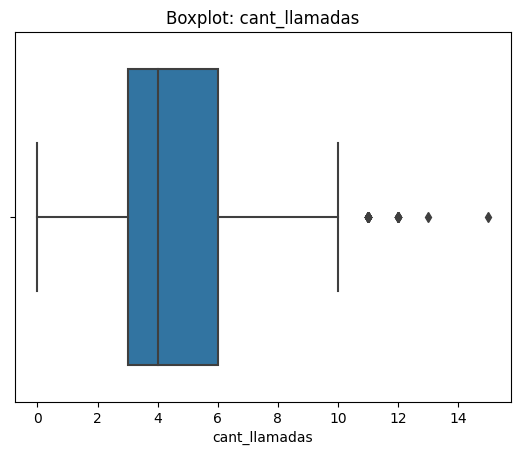

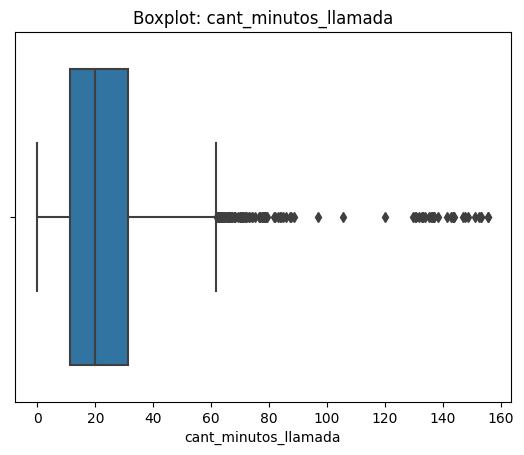

In [59]:

import seaborn as sns
import matplotlib.pyplot as plt

# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure()
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

Age: No presenta outliers extremos relevantes o son pocos y naturales para la distribución de edades.

cant_mensajes: Sí presenta outliers superiores, lo que indica usuarios con alto volumen de mensajes.

cant_llamadas: Presenta algunos outliers superiores, asociados a usuarios con alto uso.

cant_minutos_llamada: Presenta outliers superiores claros, indicando usuarios con consumo elevado.

In [60]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_superior = Q3 + 1.5 * IQR
    
    print(f"{col}")
    print(f"Límite superior: {limite_superior}")
    print(f"Valor máximo: {user_profile[col].max()}")
    print("------")



cant_mensajes
Límite superior: 11.5
Valor máximo: 17.0
------
cant_llamadas
Límite superior: 10.5
Valor máximo: 15.0
------
cant_minutos_llamada
Límite superior: 61.8575
Valor máximo: 155.69
------


In [61]:

user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000



cant_mensajes: Se recomienda mantener los outliers, ya que representan usuarios con alto uso real del servicio y no errores de captura.

cant_llamadas: Mantener los outliers, porque reflejan comportamiento real de clientes intensivos.

cant_minutos_llamada: Mantener los outliers, ya que corresponden a usuarios con alto consumo y no parecen valores imposibles.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [62]:
# Crear columna grupo_uso
# Crear columna grupo_uso

def clasificar_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

# Verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


In [63]:

# Crear columna grupo_edad

def clasificar_edad(age):
    if age <= 30:
        return 'Joven'
    elif age < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile['age'].apply(clasificar_edad)

# Verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

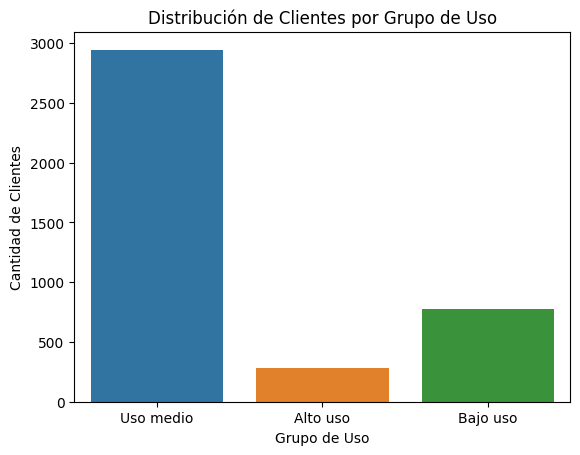

In [64]:
# Crear columna grupo_edad
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=user_profile, x='grupo_uso')
plt.title('Distribución de Clientes por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Clientes')
plt.show()

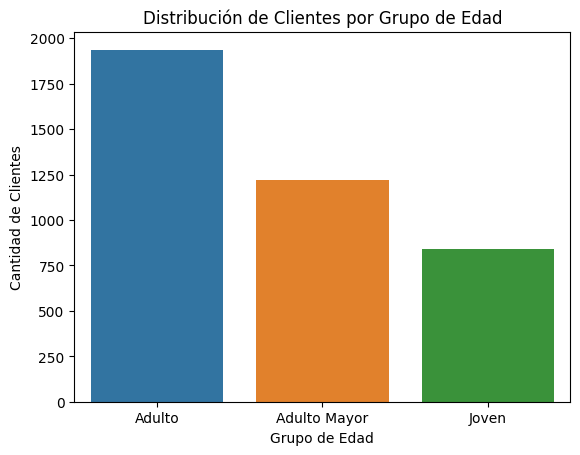

In [65]:

sns.countplot(data=user_profile, x='grupo_edad')
plt.title('Distribución de Clientes por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Clientes')
plt.show()

### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

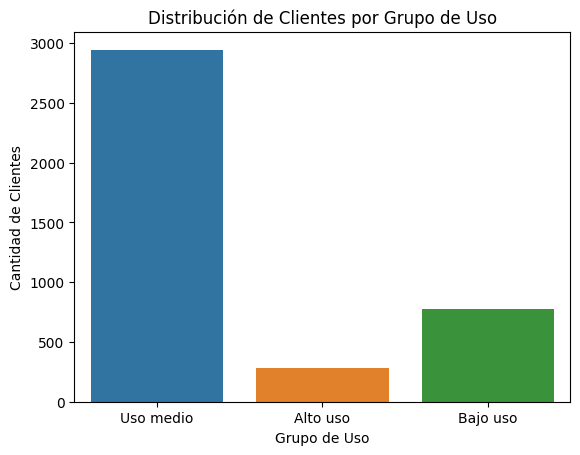

In [66]:

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=user_profile, x='grupo_uso')
plt.title('Distribución de Clientes por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Clientes')
plt.show()

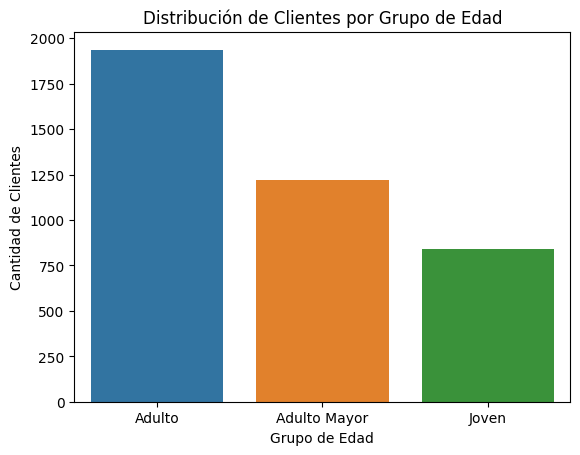

In [67]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('Distribución de Clientes por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Clientes')
plt.show()


---
## 🧩Paso 8: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
⚠️ Problemas detectados en los datos

Durante la etapa de limpieza se identificaron los siguientes problemas:

La columna age contenía valores sentinela (-999), que representaban edades inválidas. Estos registros afectaban el cálculo de estadísticas y fueron reemplazados por la mediana para evitar sesgos.

En city se encontraron valores “?” que representaban datos faltantes y fueron convertidos a nulos.

En reg_date se detectaron fechas futuras imposibles, las cuales fueron corregidas marcándolas como NA.

En duration y length, los valores nulos no eran errores sino estructurales (dependían del tipo de registro: llamadas o mensajes), por lo que se clasificaron como MAR (Missing At Random) y no requirieron imputación.

En general, los problemas detectados correspondían a un porcentaje pequeño del total de filas y no comprometían gravemente la calidad global del dataset, pero sí requerían corrección para evitar distorsiones en el análisis.

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
Se identificaron dos tipos principales de segmentación:

1️⃣ Segmentación por Edad

Joven (≤30 años)

Adulto (31–59 años)

Adulto Mayor (≥60 años)

La mayoría de los clientes se concentra en el grupo Adulto.
Los jóvenes muestran mayor tendencia al uso de mensajería, mientras que los adultos mayores presentan menor intensidad de uso general.

2️⃣ Segmentación por Nivel de Uso

Bajo uso

Uso medio

Alto uso

El grupo de Alto uso concentra clientes con mayor número de mensajes, llamadas y minutos consumidos.
El grupo de Bajo uso presenta consumo reducido y podría estar subutilizando su plan actual.
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
💰 Segmentos más valiosos para ConnectaTel

El segmento de Alto uso parece el más valioso, ya que:

Genera mayor consumo total.

Presenta mayor interacción con los servicios.

Representa oportunidad de upselling a planes premium.

También el grupo de adultos activos (31–59 años) es estratégico, ya que concentra la mayor base de clientes y un consumo constante.
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
📊 Patrones de uso extremo (Outliers)

Se identificaron valores extremos principalmente en:

cant_mensajes

cant_llamadas

cant_minutos_llamada

Estos outliers se concentran en el extremo superior, lo que indica la existencia de usuarios altamente intensivos.

No parecen errores de captura, sino clientes reales con consumo elevado. Esto implica que existe un subgrupo dispuesto a pagar por mayor capacidad o beneficios adicionales.
- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
💡 Recomendaciones Estratégicas

1️⃣ Crear un plan especializado para usuarios de alto consumo, con beneficios ampliados en llamadas y mensajería ilimitada.

2️⃣ Diseñar un plan económico optimizado para clientes de bajo uso, evitando que paguen por servicios que no utilizan y reduciendo riesgo de cancelación.

3️⃣ Implementar campañas diferenciadas por edad:

Plan digital enfocado en jóvenes (mensajes y beneficios digitales).

Plan enfocado en llamadas para adultos mayores.

4️⃣ Utilizar la segmentación para estrategias de marketing personalizado y retención, enfocándose en comportamiento real y no solo en características demográficas.
✍️ **Escribe aquí tu análisis ejecutivo:**
🎯 Conclusión General

El análisis revela que ConnectaTel tiene una base diversa de clientes con patrones claros de consumo.
La segmentación por uso permite identificar oportunidades de monetización y optimización de planes, mientras que los outliers representan clientes de alto valor que pueden impulsar mayores ingresos si se gestionan estratégicamente.

### Análisis ejecutivo

Análisis ejecutivo
⚠️ Problemas detectados en los datos

Se identificaron valores inválidos en la columna age (-999), los cuales fueron reemplazados por la mediana para evitar distorsiones en el análisis.

También se encontraron valores faltantes representados como “?” en city y fechas futuras en reg_date, que fueron corregidas.

En las variables duration y length, los valores nulos eran estructurales (dependían del tipo de registro) y no errores, por lo que se mantuvieron como NA.

🔍 Segmentos por Edad

Se clasificaron los clientes en tres grupos: Joven (≤30 años), Adulto (31–59 años) y Adulto Mayor (≥60 años).

La mayor concentración se encuentra en el grupo Adulto, lo que indica que el mercado principal está en edad productiva. Los jóvenes muestran mayor uso de mensajería, mientras que los adultos mayores presentan menor intensidad de uso general.

📊 Segmentos por Nivel de Uso

Se identificaron tres niveles: Bajo uso, Uso medio y Alto uso.

El grupo de Alto uso concentra clientes con mayor número de mensajes, llamadas y minutos consumidos, mientras que el grupo de Bajo uso presenta consumo reducido.

➡️ Esto sugiere que ...

Existe una segmentación clara entre usuarios intensivos y usuarios ocasionales.

Los clientes de alto uso representan una oportunidad de monetización adicional, mientras que los de bajo uso podrían requerir planes más ajustados a su consumo real.

💡 Recomendaciones

Diseñar un plan premium dirigido a usuarios de alto consumo con beneficios ampliados y mayor capacidad.

Crear planes económicos para usuarios de bajo uso que mejoren la retención y reduzcan el riesgo de cancelación.

Implementar estrategias diferenciadas por edad y comportamiento de uso para maximizar ingresos y satisfacción del cliente.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`